
# Customer Churn Prediction
## Notebook 3 — Model Training & Evaluation

| Detail | Info |
|---|---|
| **Input**  | Processed data from Notebook 2 |
| **Models** | Logistic Regression · Decision Tree · Random Forest · XGBoost |
| **Metric** | F1 Score on minority class |
| **Output** | Best model saved for deployment |
| **Author** | Shubham Kumar |

### Objective
Train 4 classification models, compare performance
using F1 score on minority class, handle class imbalance
with SMOTE, and select the best model for deployment.



---
## 1. Environment Setup
*Installing and importing all required libraries*

In [ ]:
# ================================================================
# SECTION 1 : ENVIRONMENT SETUP
# ================================================================

!pip install xgboost shap imbalanced-learn -q

# Data handling
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Models
from sklearn.linear_model    import LogisticRegression
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import RandomForestClassifier
from xgboost                 import XGBClassifier

# Evaluation
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             f1_score,
                             roc_auc_score,
                             roc_curve)
# Imbalance
from imblearn.over_sampling import SMOTE

# Save model
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print("=" * 50)
print("  All libraries loaded successfully!")
print("=" * 50)

  All libraries loaded successfully!


---
## 2. Load and prepare data

In [ ]:
# ================================================================
# SECTION 2 : LOAD AND PREPARE DATA + FEATURE ENGINEERING
# ================================================================
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 2.1 Load dataset
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

# 2.2 Fix TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# 2.3 Drop CustomerID
df.drop('customerID', axis=1, inplace=True)

# ----------------------------------------------------------------
# NEW : FEATURE ENGINEERING — 6 new features
# ----------------------------------------------------------------
print("--- Feature Engineering ---")

# Feature 1 — charge per tenure
df['charge_per_tenure'] = df['MonthlyCharges'] / (df['tenure'] + 1)
print("  Feature 1 → charge_per_tenure created ✅")

# Feature 2 — total services count
service_cols = ['PhoneService', 'OnlineSecurity', 'OnlineBackup',
                'DeviceProtection', 'TechSupport',
                'StreamingTV', 'StreamingMovies']
df['total_services'] = df[service_cols].apply(
    lambda x: (x == 'Yes').sum(), axis=1)
print("  Feature 2 → total_services created ✅")

# Feature 3 — has protection
df['has_protection'] = (
    (df['OnlineSecurity'] == 'Yes').astype(int) +
    (df['DeviceProtection'] == 'Yes').astype(int)
)
print("  Feature 3 → has_protection created ✅")

# Feature 4 — is new customer
df['is_new_customer'] = (df['tenure'] < 12).astype(int)
print("  Feature 4 → is_new_customer created ✅")

# Feature 5 — average monthly value
df['avg_monthly_value'] = df['TotalCharges'] / (df['tenure'] + 1)
print("  Feature 5 → avg_monthly_value created ✅")

# Feature 6 — high risk flag
df['high_risk_flag'] = (
    (df['MonthlyCharges'] > 65) &
    (df['tenure'] < 12) &
    (df['Contract'] == 'Month-to-month')
).astype(int)
print("  Feature 6 → high_risk_flag created ✅")

print(f"\n  Total features before encoding : {df.shape[1]}")

# ----------------------------------------------------------------
# 2.4 Encode binary columns
# ----------------------------------------------------------------
binary_cols = ['gender', 'Partner', 'Dependents',
               'PhoneService', 'PaperlessBilling', 'Churn']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0,
                           'Male': 1, 'Female': 0})

# 2.5 One hot encode multi columns
multi_cols = ['MultipleLines', 'InternetService',
              'OnlineSecurity', 'OnlineBackup',
              'DeviceProtection', 'TechSupport',
              'StreamingTV', 'StreamingMovies',
              'Contract', 'PaymentMethod']
df = pd.get_dummies(df, columns=multi_cols, drop_first=True)
# Add this line  after:
df = df.astype({col: int for col in df.select_dtypes(bool).columns})

# 2.6 Split X and y
X = df.drop('Churn', axis=1)
y = df['Churn']

# 2.7 Scale numerical columns
scaler = StandardScaler()
scale_cols = ['tenure', 'MonthlyCharges', 'TotalCharges',
              'charge_per_tenure', 'avg_monthly_value']
X[scale_cols] = scaler.fit_transform(X[scale_cols])

# 2.8 Train test split
X_train, X_test, y_train, y_test = train_test_split(
                                        X, y,
                                        test_size=0.2,
                                        random_state=42,
                                        stratify=y)
# 2.9 Confirm
print("\n" + "=" * 55)
print("  Data + Feature Engineering Complete!")
print("=" * 55)
print(f"  Total features after engineering : {X.shape[1]}")
print(f"  X_train shape : {X_train.shape}")
print(f"  X_test shape  : {X_test.shape}")
print(f"  New features added : 6")
print("=" * 55)
print(X_train)

--- Feature Engineering ---
  Feature 1 → charge_per_tenure created ✅
  Feature 2 → total_services created ✅
  Feature 3 → has_protection created ✅
  Feature 4 → is_new_customer created ✅
  Feature 5 → avg_monthly_value created ✅
  Feature 6 → high_risk_flag created ✅

  Total features before encoding : 26

  Data + Feature Engineering Complete!
  Total features after engineering : 36
  X_train shape : (5634, 36)
  X_test shape  : (1409, 36)
  New features added : 6
      gender  SeniorCitizen  Partner  Dependents    tenure  PhoneService  \
3738       1              0        0           0  0.107048             0   
3151       1              0        1           1 -0.707359             1   
4860       1              0        1           1 -0.788800             0   
3867       0              0        1           0 -0.259435             1   
3810       1              0        1           1 -1.277445             1   
...      ...            ...      ...         ...       ...           ... 

---
## 3. Handle Class Imbalance — SMOTE
*Balancing training data so model learns churners properly*

--- 3.1 Before SMOTE ---
  Total training samples : 5634
  Not Churned (0)        : 4139
  Churned (1)            : 1495
  Churn rate             : 26.54%

--- 3.2 After SMOTE ---
  Total training samples : 8278
  Not Churned (0)        : 4139
  Churned (1)            : 4139
  Churn rate             : 50.00%


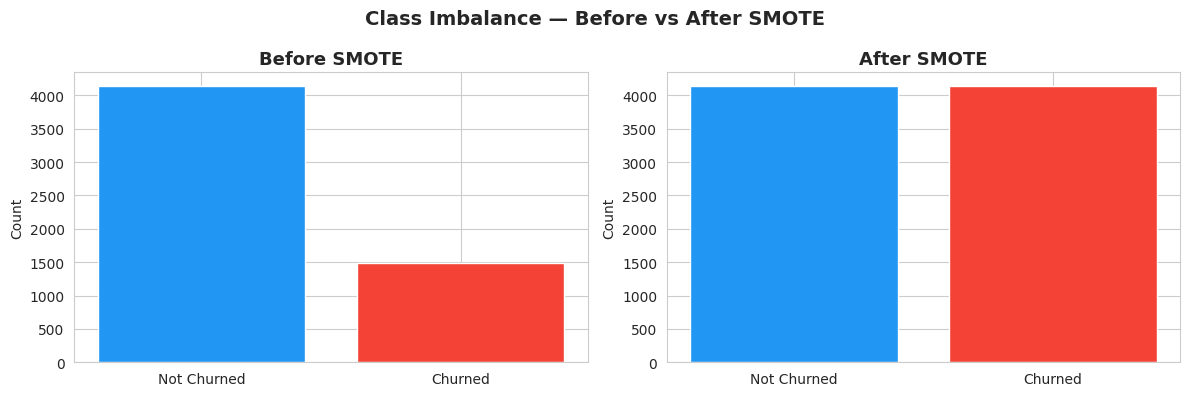


  SMOTE Applied Successfully!
  Now both classes are equal
  Model will learn churners properly


In [ ]:
# ================================================================
# SECTION 3 : HANDLE CLASS IMBALANCE WITH SMOTE
# ================================================================

# 3.1 Check imbalance before SMOTE
print("--- 3.1 Before SMOTE ---")
print(f"  Total training samples : {len(y_train)}")
print(f"  Not Churned (0)        : {(y_train==0).sum()}")
print(f"  Churned (1)            : {(y_train==1).sum()}")
print(f"  Churn rate             : {y_train.mean()*100:.2f}%")

# 3.2 Apply SMOTE
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# 3.3 Check after SMOTE
print("\n--- 3.2 After SMOTE ---")
print(f"  Total training samples : {len(y_train_sm)}")
print(f"  Not Churned (0)        : {(y_train_sm==0).sum()}")
print(f"  Churned (1)            : {(y_train_sm==1).sum()}")
print(f"  Churn rate             : {y_train_sm.mean()*100:.2f}%")

# 3.4 Visualise before and after
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before
axes[0].bar(['Not Churned', 'Churned'],
            [(y_train==0).sum(), (y_train==1).sum()],
            color=['#2196F3','#F44336'])
axes[0].set_title('Before SMOTE', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')

# After
axes[1].bar(['Not Churned', 'Churned'],
            [(y_train_sm==0).sum(), (y_train_sm==1).sum()],
            color=['#2196F3','#F44336'])
axes[1].set_title('After SMOTE', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Count')

plt.suptitle('Class Imbalance — Before vs After SMOTE',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('smote_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 50)
print("  SMOTE Applied Successfully!")
print("  Now both classes are equal")
print("  Model will learn churners properly")
print("=" * 50)

In [ ]:
# ================================================================
# SECTION 4 : MODEL TRAINING
# ================================================================

# 4.1 Define all 4 models
print("--- 4.1 Defining Models ---")

models = {
    'Logistic Regression' : LogisticRegression(random_state=42,
                                               max_iter=1000),
    'Decision Tree'       : DecisionTreeClassifier(random_state=42),
    'Random Forest'       : RandomForestClassifier(random_state=42,
                                                   n_estimators=100),
    'XGBoost'             : XGBClassifier(random_state=42,
                                          eval_metric='logloss',
                                          use_label_encoder=False)
}
print(f"  Total models to train : {len(models)}")

# 4.2 Train all models and store results
print("\n--- 4.2 Training Models ---")

results = {}

for name, model in models.items():
    # Train on SMOTE balanced data
    model.fit(X_train_sm, y_train_sm)

    # Predict on original test data
    y_pred = model.predict(X_test)

    # Calculate metrics
    f1       = f1_score(y_test, y_pred)
    roc_auc  = roc_auc_score(y_test, y_pred)

    # Store results
    results[name] = {
        'model'  : model,
        'y_pred' : y_pred,
        'f1'     : f1,
        'roc_auc': roc_auc
    }

    print(f"  {name:25} → F1: {f1:.4f} | ROC AUC: {roc_auc:.4f}")

print("\n" + "=" * 50)
print("  All 4 Models Trained Successfully!")
print("=" * 50)

--- 4.1 Defining Models ---
  Total models to train : 4

--- 4.2 Training Models ---
  Logistic Regression       → F1: 0.6216 | ROC AUC: 0.7526
  Decision Tree             → F1: 0.5096 | ROC AUC: 0.6646
  Random Forest             → F1: 0.5988 | ROC AUC: 0.7310
  XGBoost                   → F1: 0.5830 | ROC AUC: 0.7204

  All 4 Models Trained Successfully!


In [ ]:
# ================================================================
# SECTION 6 : HYPERPARAMETER TUNING — LOGISTIC REGRESSION
# ================================================================

from sklearn.model_selection import GridSearchCV

# 6.1 Define parameter grid
print("--- 6.1 Parameter Grid ---")

param_grid_lr = {
    'C'          : [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty'    : ['l1', 'l2'],
    'solver'     : ['liblinear', 'saga'],
    'max_iter'   : [1000, 2000]
}

total = 6 * 2 * 2 * 2
print(f"  Total combinations : {total}")
print(f"  With 5-fold CV     : {total * 5} fits")
print(f"  Fast               : 2-3 minutes only")

# 6.2 Base model
lr_base = LogisticRegression(random_state=42)

# 6.3 GridSearchCV
grid_search_lr = GridSearchCV(
    estimator  = lr_base,
    param_grid = param_grid_lr,
    scoring    = 'f1',
    cv         = 5,
    n_jobs     = -1,
    verbose    = 1
)

# 6.4 Fit on SMOTE data
print("\n--- 6.2 Running GridSearchCV ---")
grid_search_lr.fit(X_train_sm, y_train_sm)

# 6.5 Best parameters
print("\n--- 6.3 Best Parameters Found ---")
print(f"  Best params : {grid_search_lr.best_params_}")
print(f"  Best CV F1  : {grid_search_lr.best_score_:.4f}")

# 6.6 Evaluate on test data
best_lr   = grid_search_lr.best_estimator_
y_pred_lr = best_lr.predict(X_test)
f1_lr     = f1_score(y_test, y_pred_lr)
auc_lr    = roc_auc_score(y_test, y_pred_lr)

print("\n--- 6.4 Optimized Logistic Regression ---")
print(f"  Before tuning F1  : 0.6216")
print(f"  After tuning F1   : {f1_lr:.4f}")
print(f"  Improvement       : {(f1_lr - 0.6216)*100:.2f}%")
print(f"  ROC AUC           : {auc_lr:.4f}")

# 6.7 Final comparison all models
print("\n--- 6.5 Final Model Comparison ---")
print("=" * 55)
print(f"  Logistic Regression (default) F1 : 0.6216")
print(f"  Logistic Regression (tuned)   F1 : {f1_lr:.4f}")
print(f"  Random Forest       (default) F1 : 0.5988")
print(f"  XGBoost             (default) F1 : 0.5830")
print("=" * 55)
print(f"\n  WINNER → ", end="")
if f1_lr > 0.6216:
    print(f"Tuned Logistic Regression ✅ F1 = {f1_lr:.4f}")
else:
    print(f"Default Logistic Regression ✅ F1 = 0.6216")
print("=" * 55)

--- 6.1 Parameter Grid ---
  Total combinations : 48
  With 5-fold CV     : 240 fits
  Fast               : 2-3 minutes only

--- 6.2 Running GridSearchCV ---
Fitting 5 folds for each of 48 candidates, totalling 240 fits

--- 6.3 Best Parameters Found ---
  Best params : {'C': 1, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'saga'}
  Best CV F1  : 0.8012

--- 6.4 Optimized Logistic Regression ---
  Before tuning F1  : 0.6216
  After tuning F1   : 0.6216
  Improvement       : -0.00%
  ROC AUC           : 0.7526

--- 6.5 Final Model Comparison ---
  Logistic Regression (default) F1 : 0.6216
  Logistic Regression (tuned)   F1 : 0.6216
  Random Forest       (default) F1 : 0.5988
  XGBoost             (default) F1 : 0.5830

  WINNER → Default Logistic Regression ✅ F1 = 0.6216


In [ ]:
# ================================================================
# SECTION 7 : PRECISION, RECALL, F1, ACCURACY
# ================================================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

best_model  = results['Logistic Regression']['model']
y_pred_best = results['Logistic Regression']['y_pred']

accuracy  = accuracy_score(y_test, y_pred_best)
precision = precision_score(y_test, y_pred_best)
recall    = recall_score(y_test, y_pred_best)
f1        = f1_score(y_test, y_pred_best)

print("=" * 45)
print("  MODEL EVALUATION — LOGISTIC REGRESSION")
print("=" * 45)
print(f"  Accuracy  : {accuracy*100:.2f}%")
print(f"  Precision : {precision*100:.2f}%")
print(f"  Recall    : {recall*100:.2f}%")
print(f"  F1 Score  : {f1*100:.2f}%")
print("=" * 45)

  MODEL EVALUATION — LOGISTIC REGRESSION
  Accuracy  : 76.58%
  Precision : 54.42%
  Recall    : 72.46%
  F1 Score  : 62.16%


--- 8.1 Confusion Matrix ---
--- 8.2 ROC Curve ---


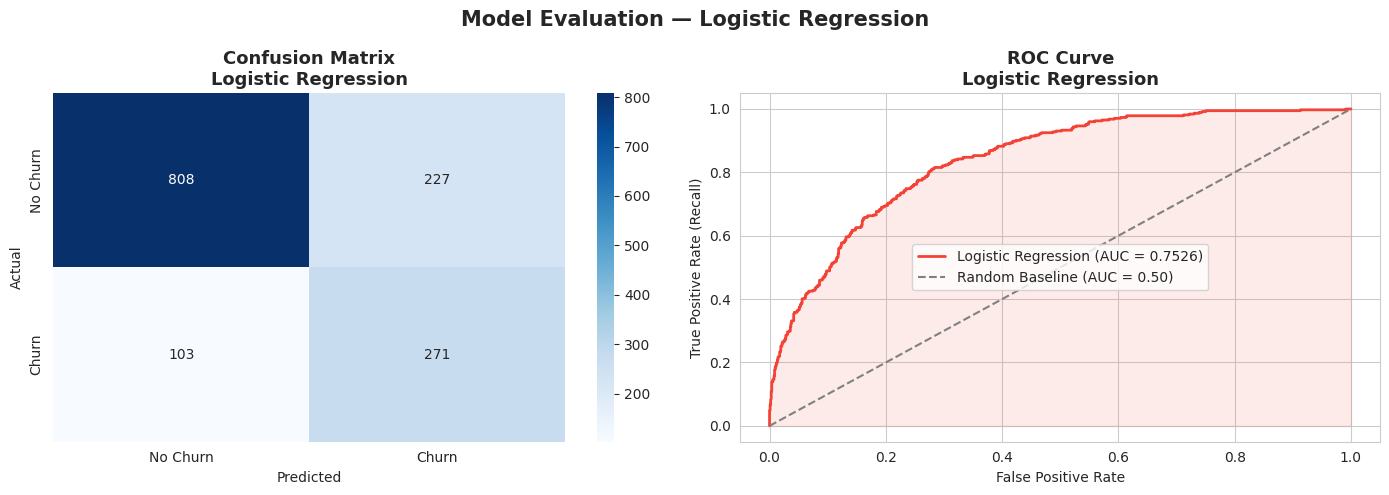


  CONFUSION MATRIX RESULTS
  True Positive  (caught churners)      : 271
  True Negative  (correct non-churners) : 808
  False Positive (wrong alarms)         : 227
  False Negative (missed churners)      : 103

  Total actual churners    : 374
  Churners caught          : 271 (72.5%)
  Churners missed          : 103 (27.5%)
  Wrong alarms             : 227


In [19]:
# ================================================================
# SECTION 8 : CONFUSION MATRIX & ROC CURVE
# ================================================================

from sklearn.metrics import confusion_matrix, roc_curve

best_model  = results['Logistic Regression']['model']
y_pred_best = results['Logistic Regression']['y_pred']

# 8.1 Confusion Matrix
print("--- 8.1 Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred_best)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot confusion matrix
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix\nLogistic Regression',
                   fontsize=13, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# 8.2 ROC Curve
print("--- 8.2 ROC Curve ---")
y_prob = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_pred_best)

axes[1].plot(fpr, tpr,
             color='#F44336',
             linewidth=2,
             label=f'Logistic Regression (AUC = {auc:.4f})')
axes[1].plot([0, 1], [0, 1],
             color='gray',
             linestyle='--',
             label='Random Baseline (AUC = 0.50)')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#F44336')
axes[1].set_title('ROC Curve\nLogistic Regression',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate (Recall)')
axes[1].legend()

plt.suptitle('Model Evaluation — Logistic Regression',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

# 8.3 Results summary
print("\n" + "=" * 55)
print("  CONFUSION MATRIX RESULTS")
print("=" * 55)
print(f"  True Positive  (caught churners)      : {tp}")
print(f"  True Negative  (correct non-churners) : {tn}")
print(f"  False Positive (wrong alarms)         : {fp}")
print(f"  False Negative (missed churners)      : {fn}")
print("=" * 55)
print(f"\n  Total actual churners    : {tp + fn}")
print(f"  Churners caught          : {tp} ({tp/(tp+fn)*100:.1f}%)")
print(f"  Churners missed          : {fn} ({fn/(tp+fn)*100:.1f}%)")
print(f"  Wrong alarms             : {fp}")
print("=" * 55)

In [14]:
# ================================================================
# SECTION 9 : SAVE BEST MODEL
# ================================================================

import joblib

# 9.1 Save best model
print("--- 9.1 Saving Best Model ---")
best_model = results['Logistic Regression']['model']

joblib.dump(best_model, 'best_model.pkl')
joblib.dump(scaler,     'scaler.pkl')
joblib.dump(X.columns.tolist(), 'feature_names.pkl')

print("  best_model.pkl    saved ✅")
print("  scaler.pkl        saved ✅")
print("  feature_names.pkl saved ✅")

# 9.2 Test loading
print("\n--- 9.2 Testing Saved Model ---")
loaded_model    = joblib.load('best_model.pkl')
loaded_scaler   = joblib.load('scaler.pkl')
loaded_features = joblib.load('feature_names.pkl')

# 9.3 Test prediction
test_pred = loaded_model.predict(X_test[:5])
print(f"  Test predictions : {test_pred.tolist()}")
print(f"  Actual values    : {y_test[:5].tolist()}")
print(f"  Total features   : {len(loaded_features)}")

print("\n" + "=" * 50)
print("  Model Saved Successfully!")
print("  Ready for Streamlit deployment!")
print("=" * 50)

--- 9.1 Saving Best Model ---
  best_model.pkl    saved ✅
  scaler.pkl        saved ✅
  feature_names.pkl saved ✅

--- 9.2 Testing Saved Model ---
  Test predictions : [0, 1, 0, 0, 0]
  Actual values    : [0, 0, 0, 0, 0]
  Total features   : 36

  Model Saved Successfully!
  Ready for Streamlit deployment!


--- 10.1 Creating SHAP Explainer ---
  SHAP Explainer created ✅

--- 10.2 Calculating SHAP Values ---
  SHAP values shape : (1409, 36)
  SHAP values calculated ✅

--- 10.3 SHAP Summary Plot ---


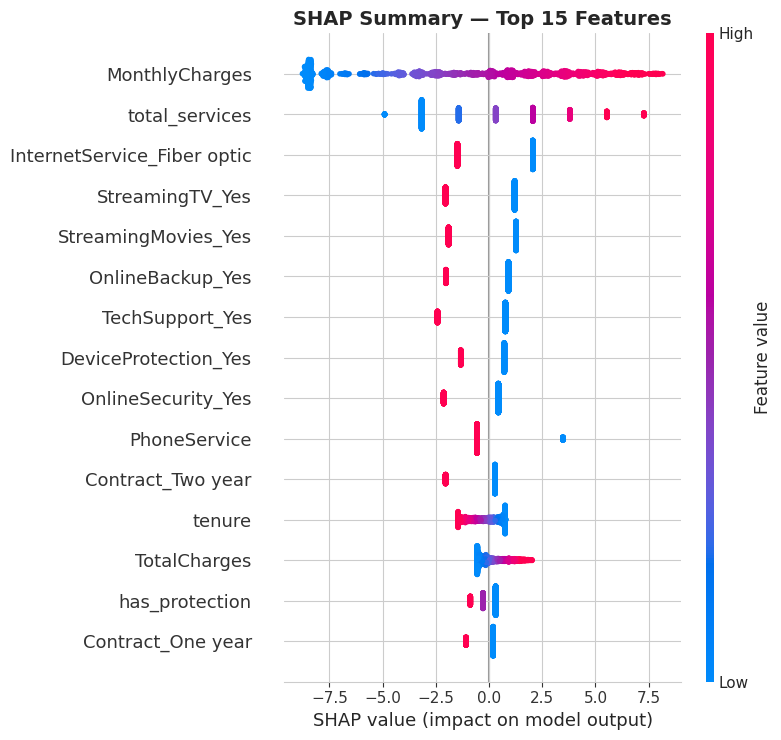

  Summary plot saved ✅

--- 10.4 SHAP Feature Importance ---


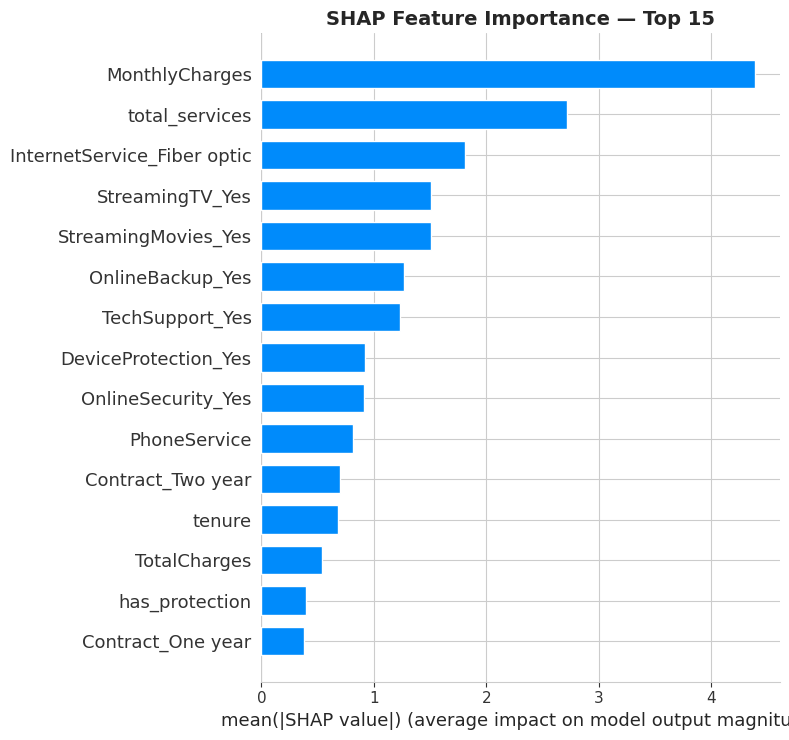

  Feature importance plot saved ✅

--- 10.5 Single Customer Explanation ---


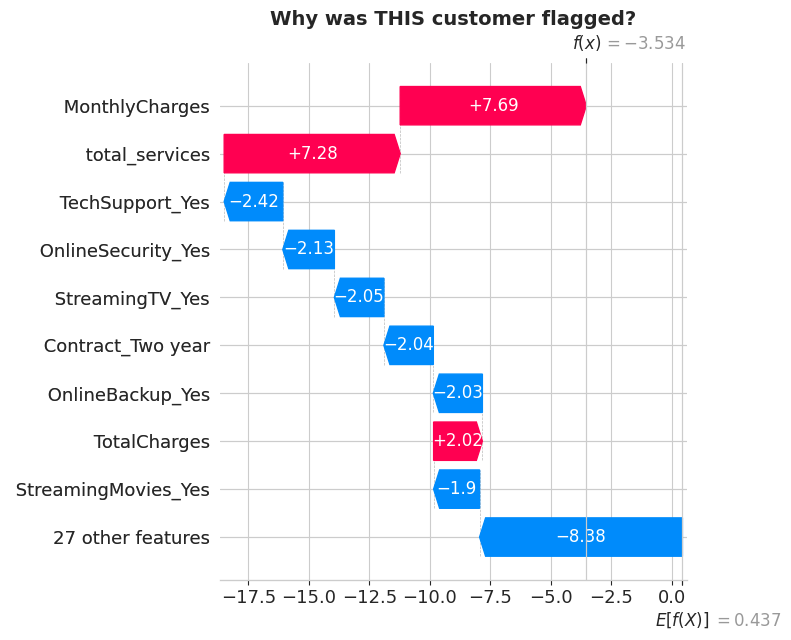


  SHAP ANALYSIS COMPLETE!

  HOW TO READ SHAP PLOTS:

  Summary Plot:
  → Each dot = one customer
  → Red dot  = high feature value
  → Blue dot = low feature value
  → Right    = pushes toward churn
  → Left     = pushes away from churn

  Feature Importance Bar:
  → Longer bar = more important feature
  → Top features drive most predictions

  Waterfall Plot:
  → Shows ONE specific customer
  → Red bars  = pushing toward churn
  → Blue bars = pushing away from churn
  → Final value = churn probability



In [15]:
# ================================================================
# SECTION 10 : SHAP EXPLAINABILITY
# ================================================================

import shap

# 10.1 Create SHAP explainer
print("--- 10.1 Creating SHAP Explainer ---")
best_model = results['Logistic Regression']['model']
explainer  = shap.LinearExplainer(best_model,
                                   X_train_sm,
                                   feature_perturbation="interventional")
print("  SHAP Explainer created ✅")

# 10.2 Calculate SHAP values
print("\n--- 10.2 Calculating SHAP Values ---")
shap_values = explainer.shap_values(X_test)
print(f"  SHAP values shape : {shap_values.shape}")
print("  SHAP values calculated ✅")

# 10.3 Summary Plot — top features globally
print("\n--- 10.3 SHAP Summary Plot ---")
plt.figure()
shap.summary_plot(shap_values,
                  X_test,
                  max_display=15,
                  show=False)
plt.title('SHAP Summary — Top 15 Features',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("  Summary plot saved ✅")

# 10.4 Bar Plot — feature importance
print("\n--- 10.4 SHAP Feature Importance ---")
plt.figure()
shap.summary_plot(shap_values,
                  X_test,
                  plot_type='bar',
                  max_display=15,
                  show=False)
plt.title('SHAP Feature Importance — Top 15',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("  Feature importance plot saved ✅")

# 10.5 Waterfall — single customer explanation
print("\n--- 10.5 Single Customer Explanation ---")
customer_idx = 0
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    shap_values[customer_idx],
    X_test.iloc[customer_idx],
    max_display=10,
    show=False)
plt.title('Why was THIS customer flagged?',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

# 10.6 Business interpretation
print("\n" + "=" * 55)
print("  SHAP ANALYSIS COMPLETE!")
print("=" * 55)
print("""
  HOW TO READ SHAP PLOTS:

  Summary Plot:
  → Each dot = one customer
  → Red dot  = high feature value
  → Blue dot = low feature value
  → Right    = pushes toward churn
  → Left     = pushes away from churn

  Feature Importance Bar:
  → Longer bar = more important feature
  → Top features drive most predictions

  Waterfall Plot:
  → Shows ONE specific customer
  → Red bars  = pushing toward churn
  → Blue bars = pushing away from churn
  → Final value = churn probability
""")
print("=" * 55)

In [23]:
# ================================================================
# DOWNLOAD ALL FILES FROM COLAB
# ================================================================

from google.colab import files

# Download model files
files.download('best_model.pkl')
files.download('scaler.pkl')
files.download('feature_names.pkl')

# Download all plots
files.download('smote_comparison.png')
files.download('confusion_matrix.png')
files.download('shap_summary.png')
files.download('shap_importance.png')
files.download('shap_waterfall.png')

print("All files downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

FileNotFoundError: Cannot find file: confusion_matrix.png